# Notebook 3: Student Model + SHAP Explainability
Trains the thin-file model using teacher soft labels. Produces credit scores, risk tiers, decisions, and SHAP-based explanations.

In [1]:
import pandas as pd
import numpy as np
import json, pickle, warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
import shap

# ── Load ───────────────────────────────────────────────────────────────────
thick = pd.read_parquet('thick_with_soft_labels.parquet')
with open('feature_sets.json') as f:
    fs = json.load(f)
STUDENT_FEATURES = fs['student']

# Student trains on ALL users — but with only non-history features
# Thin-file users have 0 for history cols (already imputed in NB1)
# so their student-feature space is complete and valid
X = thick[STUDENT_FEATURES]
y_soft = thick['SOFT_LABEL']          # teacher's soft probability
y_hard = thick['TARGET']              # original binary label (for eval only)
is_thin = thick['IS_THIN_FILE']

print(f'All users: {X.shape}')
print(f'Thin-file users: {is_thin.sum()}')
print(f'Student features: {len(STUDENT_FEATURES)}')

All users: (307511, 26)
Thin-file users: 2240
Student features: 26


## 1. Train/Val Split
Stratify on hard labels to preserve default rate across splits.

In [2]:
X_tr, X_val, y_tr, y_val, yh_tr, yh_val, thin_tr, thin_val = train_test_split(
    X, y_soft, y_hard, is_thin,
    test_size=0.2, stratify=y_hard, random_state=42
)
print(f'Train: {X_tr.shape} | Val: {X_val.shape}')

Train: (246008, 26) | Val: (61503, 26)


## 2. Student Model: Regression on Soft Labels
Using regression (not classification) because:
- Soft labels are continuous probabilities, not integers
- MSE loss preserves teacher's confidence gradations
- Output clipped to [0,1] post-training

In [3]:
student = XGBRegressor(
    n_estimators      = 400,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    eval_metric       = 'rmse',
    early_stopping_rounds = 30,
    random_state      = 42,
    tree_method       = 'hist',
    verbosity         = 0,
)

student.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100
)

val_pred_raw = student.predict(X_val)
val_pred = np.clip(val_pred_raw, 0, 1)

rmse = np.sqrt(mean_squared_error(y_val, val_pred))
rho, _  = spearmanr(val_pred, y_val)
print(f'Val RMSE vs soft labels : {rmse:.4f}')
print(f'Spearman rho (rank corr): {rho:.4f}')

[0]	validation_0-rmse:0.07042
[100]	validation_0-rmse:0.05148
[200]	validation_0-rmse:0.05028
[300]	validation_0-rmse:0.04983
[399]	validation_0-rmse:0.04961
Val RMSE vs soft labels : 0.0496
Spearman rho (rank corr): 0.7348


## 3. Evaluate Student on Thin-File Users Specifically

In [4]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Thin-file validation subset
thin_mask = thin_val == 1
thick_mask = thin_val == 0

def eval_subset(mask, label):
    if mask.sum() == 0:
        print(f'{label}: no samples')
        return
    preds = val_pred[mask]
    truth = yh_val[mask]
    if truth.nunique() < 2:
        print(f'{label}: only one class in subset, skipping AUC')
        return
    auc = roc_auc_score(truth, preds)
    pr  = average_precision_score(truth, preds)
    print(f'{label:15s} | n={mask.sum():5d} | ROC-AUC={auc:.4f} | PR-AUC={pr:.4f}')

eval_subset(thin_mask,  'Thin-file')
eval_subset(thick_mask, 'Thick-file')

Thin-file       | n=  447 | ROC-AUC=0.7083 | PR-AUC=0.2136
Thick-file      | n=61056 | ROC-AUC=0.6887 | PR-AUC=0.1737


## 4. Credit Score Mapping
Log-odds transformation: score = A - B × log(p / (1-p))
- A, B chosen so score=600 at odds=1:1 and +20 pts per odds doubling
- Range clipped to [300, 900]

In [5]:
def prob_to_score(p, pdo=20, base_score=600, base_odds=1.0):
    """Industry-standard log-odds scaling."""
    p = np.clip(p, 1e-6, 1 - 1e-6)
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)
    log_odds = np.log(p / (1 - p))
    score = offset - factor * log_odds
    return np.clip(score, 300, 900).astype(int)

def get_tier(score):
    if score >= 750: return 'Excellent'
    if score >= 700: return 'Good'
    if score >= 650: return 'Fair'
    if score >= 600: return 'Poor'
    return 'Very Poor'

def get_decision(prob):
    if prob < 0.10:  return 'APPROVE'
    if prob < 0.25:  return 'REVIEW'
    return 'REJECT'

# Verify distribution
sample_probs = np.linspace(0.01, 0.99, 10)
for p in sample_probs:
    s = prob_to_score(p)
    print(f'P(default)={p:.2f} → score={s:3d} | {get_tier(s):10s} | {get_decision(p)}')

P(default)=0.01 → score=732 | Good       | APPROVE
P(default)=0.12 → score=657 | Fair       | REVIEW
P(default)=0.23 → score=635 | Poor       | REVIEW
P(default)=0.34 → score=619 | Poor       | REJECT
P(default)=0.45 → score=606 | Poor       | REJECT
P(default)=0.55 → score=593 | Very Poor  | REJECT
P(default)=0.66 → score=580 | Very Poor  | REJECT
P(default)=0.77 → score=564 | Very Poor  | REJECT
P(default)=0.88 → score=542 | Very Poor  | REJECT
P(default)=0.99 → score=467 | Very Poor  | REJECT


## 5. SHAP Explainability
TreeExplainer is exact (not approximate) for tree models — no sampling error.

In [6]:
# Build explainer on training data background (500 samples is sufficient)
background = shap.maskers.Independent(X_tr, max_samples=500)
explainer = shap.TreeExplainer(student, data=background)

# Compute SHAP on validation set (thin-file subset for demo)
X_thin_val = X_val[thin_mask]
shap_values_thin = explainer.shap_values(X_thin_val)

print(f'SHAP values shape: {shap_values_thin.shape}')
print('SHAP mean |impact| per feature (top 10):')
mean_shap = pd.Series(
    np.abs(shap_values_thin).mean(axis=0),
    index=STUDENT_FEATURES
).sort_values(ascending=False)
print(mean_shap.head(10).round(5).to_string())

 99%|===================| 442/447 [00:37<00:00]        

SHAP values shape: (447, 26)
SHAP mean |impact| per feature (top 10):
CREDIT_TO_GOODS               0.01445
NAME_EDUCATION_TYPE           0.01415
AGE_YEARS                     0.01393
AMT_GOODS_PRICE               0.01320
AMT_ANNUITY                   0.01176
EMPLOYED_YEARS                0.01073
REGION_POPULATION_RELATIVE    0.00558
OCCUPATION_TYPE               0.00510
FLAG_OWN_CAR                  0.00497
NAME_INCOME_TYPE              0.00486


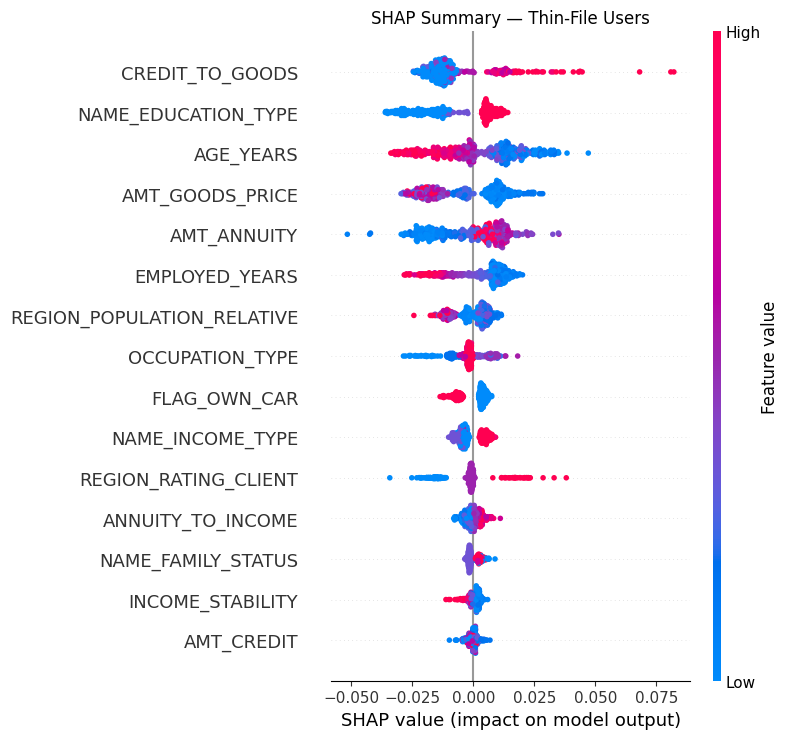

In [7]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values_thin, X_thin_val,
    feature_names=STUDENT_FEATURES,
    max_display=15,
    show=False
)
plt.title('SHAP Summary — Thin-File Users')
plt.tight_layout()
plt.savefig('shap_summary_thin_file.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Per-User Explanation Function
This is what the demo UI calls. Returns structured JSON output.

In [8]:
def score_user(user_features: pd.DataFrame, explainer, student_model, feature_names, top_n=3):
    """
    Score a single user and return full explainable output.
    user_features: single-row DataFrame with STUDENT_FEATURES columns
    """
    prob = float(np.clip(student_model.predict(user_features)[0], 0, 1))
    score = int(prob_to_score(prob))

    # SHAP for this specific user
    sv = explainer.shap_values(user_features)[0]  # shape: (n_features,)

    # Top risk drivers (positive SHAP = increases default prob = bad)
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'value': user_features.values[0],
        'shap': sv
    })

    risk_drivers = (
        shap_df[shap_df['shap'] > 0]
        .sort_values('shap', ascending=False)
        .head(top_n)
    )
    protective = (
        shap_df[shap_df['shap'] < 0]
        .sort_values('shap')
        .head(top_n)
    )

    def fmt_reason(row):
        direction = 'High' if row['shap'] > 0 else 'Low'
        return f"{direction} {row['feature'].replace('_', ' ').title()} ({row['value']:.3f})"

    return {
        'default_probability': round(prob, 4),
        'credit_score': score,
        'tier': get_tier(score),
        'decision': get_decision(prob),
        'loan_eligible': get_decision(prob) in ('APPROVE', 'REVIEW'),
        'risk_drivers':  [fmt_reason(r) for _, r in risk_drivers.iterrows()],
        'protective_factors': [fmt_reason(r) for _, r in protective.iterrows()],
    }


# ── Demo: score a thin-file user from validation set ──────────────────────
sample_idx = X_thin_val.index[0]
sample_user = X_thin_val.loc[[sample_idx]]
result = score_user(sample_user, explainer, student, STUDENT_FEATURES)

import json
print(json.dumps(result, indent=2))

{
  "default_probability": 0.0936,
  "credit_score": 665,
  "tier": "Fair",
  "decision": "APPROVE",
  "loan_eligible": true,
  "risk_drivers": [
    "High Amt Goods Price (180000.000)",
    "High Employed Years (0.534)",
    "High Name Education Type (4.000)"
  ],
  "protective_factors": [
    "Low Credit To Goods (1.158)",
    "Low Name Income Type (1.000)",
    "Low Amt Annuity (20133.000)"
  ]
}


## 7. Batch Scoring Demo (Thin-File Validation Set)

In [9]:
# Score all thin-file val users
thin_probs = np.clip(student.predict(X_thin_val), 0, 1)
thin_scores = prob_to_score(thin_probs)

results_df = pd.DataFrame({
    'default_probability': thin_probs.round(4),
    'credit_score': thin_scores,
    'tier': [get_tier(s) for s in thin_scores],
    'decision': [get_decision(p) for p in thin_probs],
    'true_label': yh_val[thin_mask].values
})

print('Decision distribution (thin-file users):')
print(results_df['decision'].value_counts())
print()
print('Score distribution:')
print(results_df['credit_score'].describe().round(0))
print()
print('Tier distribution:')
print(results_df['tier'].value_counts())

Decision distribution (thin-file users):
decision
APPROVE    376
REVIEW      69
REJECT       2
Name: count, dtype: int64

Score distribution:
count    447.0
mean     684.0
std       25.0
min      625.0
25%      670.0
50%      681.0
75%      694.0
max      900.0
Name: credit_score, dtype: float64

Tier distribution:
tier
Fair         346
Good          82
Poor          16
Excellent      3
Name: count, dtype: int64


## 8. Save Student Model & Explainer

In [10]:
with open('student_model.pkl', 'wb') as f:
    pickle.dump(student, f)

with open('shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

results_df.to_csv('thin_file_scored_results.csv', index=False)

print('Saved: student_model.pkl')
print('Saved: shap_explainer.pkl')
print('Saved: thin_file_scored_results.csv')
print()
print('System is ready for inference.')

Saved: student_model.pkl
Saved: shap_explainer.pkl
Saved: thin_file_scored_results.csv

System is ready for inference.


## 9. Inference Wrapper (Production-ready)
Call this function directly for demo or API integration.

In [11]:
class ThinFileCreditScorer:
    """
    End-to-end inference for thin-file credit scoring.
    Load once, call .predict() per user.
    """
    def __init__(self, model_path, explainer_path, encoders_path, feature_set_path):
        with open(model_path, 'rb')    as f: self.model    = pickle.load(f)
        with open(explainer_path, 'rb') as f: self.explainer = pickle.load(f)
        with open(encoders_path, 'rb')  as f: self.encoders  = pickle.load(f)
        with open(feature_set_path)     as f: self.features  = json.load(f)['student']

    def preprocess(self, raw: dict) -> pd.DataFrame:
        """Encode and engineer features from raw user input dict."""
        df = pd.DataFrame([raw])
        df['AGE_YEARS']         = -df['DAYS_BIRTH'] / 365
        df['EMPLOYED_YEARS']    = df['DAYS_EMPLOYED'].apply(lambda x: -x/365 if x < 0 else 0)
        df['DEBT_TO_INCOME']    = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
        df['ANNUITY_TO_INCOME'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
        df['CREDIT_TO_GOODS']   = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + 1)
        df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
        df['CHILDREN_RATIO']    = df['CNT_CHILDREN'] / (df['CNT_FAM_MEMBERS'] + 1)
        df['EMI_BURDEN']        = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
        df['INCOME_STABILITY']  = df['EMPLOYED_YEARS'] / (df['AGE_YEARS'] + 1)
        df['LOAN_TO_INCOME']    = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] * 12 + 1)
        df['FLAG_OWN_CAR']      = (df['FLAG_OWN_CAR'] == 'Y').astype(int)
        df['FLAG_OWN_REALTY']   = (df['FLAG_OWN_REALTY'] == 'Y').astype(int)

        cat_cols = list(self.encoders.keys())
        for col in cat_cols:
            df[col] = df[col].fillna('Unknown')
            le = self.encoders[col]
            df[col] = df[col].apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else 0
            )

        # Ensure all required features are present
        for feat in self.features:
            if feat not in df.columns:
                df[feat] = 0

        return df[self.features].fillna(0)

    def predict(self, raw: dict) -> dict:
        X = self.preprocess(raw)
        return score_user(X, self.explainer, self.model, self.features)


# ── Usage example ──────────────────────────────────────────────────────────
scorer = ThinFileCreditScorer(
    'student_model.pkl',
    'shap_explainer.pkl',
    'label_encoders.pkl',
    'feature_sets.json'
)

example_user = {
    'CNT_CHILDREN': 0,
    'CNT_FAM_MEMBERS': 2,
    'NAME_EDUCATION_TYPE': 'Higher education',
    'NAME_FAMILY_STATUS': 'Married',
    'NAME_INCOME_TYPE': 'Working',
    'OCCUPATION_TYPE': 'Laborers',
    'ORGANIZATION_TYPE': 'Business Entity Type 3',
    'NAME_HOUSING_TYPE': 'House / apartment',
    'DAYS_BIRTH': -12000,        # ~33 years old
    'DAYS_EMPLOYED': -1825,      # 5 years employed
    'FLAG_OWN_CAR': 'N',
    'FLAG_OWN_REALTY': 'Y',
    'AMT_INCOME_TOTAL': 180000,
    'AMT_CREDIT': 450000,
    'AMT_ANNUITY': 22500,
    'AMT_GOODS_PRICE': 400000,
    'REGION_POPULATION_RELATIVE': 0.035,
    'REGION_RATING_CLIENT': 2,
}

output = scorer.predict(example_user)
print(json.dumps(output, indent=2))

{
  "default_probability": 0.08,
  "credit_score": 670,
  "tier": "Fair",
  "decision": "APPROVE",
  "loan_eligible": true,
  "risk_drivers": [
    "High Age Years (32.877)",
    "High Amt Goods Price (400000.000)",
    "High Occupation Type (8.000)"
  ],
  "protective_factors": [
    "Low Name Education Type (1.000)",
    "Low Region Population Relative (0.035)",
    "Low Credit To Goods (1.125)"
  ]
}
